In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Generate sample data - 3 clusters
def generate_data():
    # Cluster 1: centered at (2, 2)
    cluster1 = torch.randn(30, 2) * 0.5 + torch.tensor([2.0, 2.0])
    
    # Cluster 2: centered at (7, 3)
    cluster2 = torch.randn(30, 2) * 0.5 + torch.tensor([7.0, 3.0])
    
    # Cluster 3: centered at (5, 8)
    cluster3 = torch.randn(30, 2) * 0.5 + torch.tensor([5.0, 8.0])
    
    # Combine all clusters
    data = torch.cat([cluster1, cluster2, cluster3], dim=0)
    
    return data

# Generate data
X = generate_data()
print(f"Data shape: {X.shape}")
print(f"First 5 data points:\n{X[:5]}")

Data shape: torch.Size([90, 2])
First 5 data points:
tensor([[2.9635, 2.7436],
        [2.4504, 0.9472],
        [2.3392, 1.3827],
        [1.9785, 1.1977],
        [1.6239, 2.8244]])


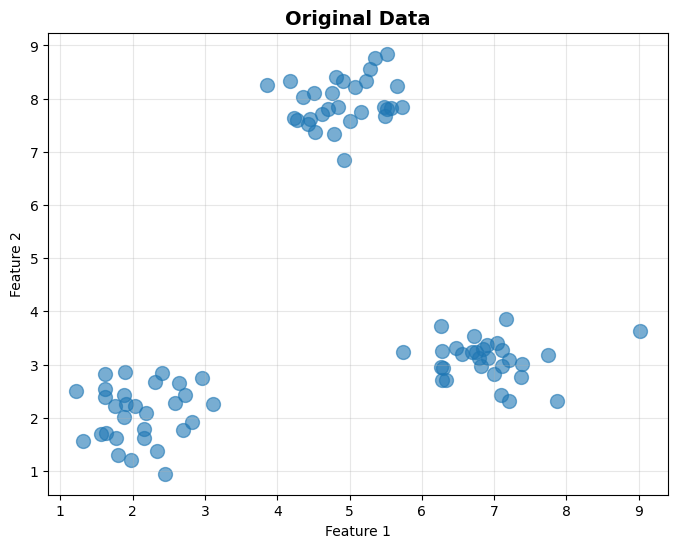

In [3]:
# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=100)
plt.title('Original Data', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class FuzzyCMeans:
    def __init__(self, n_clusters=3, m=2.0, max_iters=100, tolerance=1e-4):
        """
        Fuzzy C-Means clustering implementation from scratch
        
        Parameters:
        -----------
        n_clusters : int
            Number of clusters
        m : float
            Fuzziness parameter (m > 1)
            - m = 1: Hard clustering (not valid for FCM)
            - m = 2: Most common value (moderate fuzziness)
            - m > 2: Higher fuzziness
        max_iters : int
            Maximum number of iterations
        tolerance : float
            Convergence tolerance
        """
        if m <= 1:
            raise ValueError("Fuzziness parameter m must be > 1")
        
        self.n_clusters = n_clusters
        self.m = m
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.centroids = None
        self.membership = None  # Membership matrix
        self.labels = None  # Hard labels (highest membership)
        
    def initialize_membership(self, n_samples):
        """
        Initialize membership matrix randomly
        Each row sums to 1 (constraint: sum of memberships = 1 for each point)
        
        Returns:
        --------
        membership : torch.Tensor
            Shape (n_samples, n_clusters)
        """
        # Random initialization
        membership = torch.rand(n_samples, self.n_clusters)
        
        # Normalize so each row sums to 1
        membership = membership / membership.sum(dim=1, keepdim=True)
        
        return membership
    
    def compute_centroids(self, X, membership):
        """
        Compute cluster centroids using weighted means
        
        Formula:
        c_j = (sum of u_ij^m * x_i) / (sum of u_ij^m)
        
        Parameters:
        -----------
        X : torch.Tensor
            Data points of shape (n_samples, n_features)
        membership : torch.Tensor
            Membership matrix of shape (n_samples, n_clusters)
        
        Returns:
        --------
        centroids : torch.Tensor
            Cluster centers of shape (n_clusters, n_features)
        """
        # Raise membership to power m
        membership_m = membership ** self.m  # (n_samples, n_clusters)
        
        # Compute weighted sum: membership_m^T @ X
        # membership_m^T: (n_clusters, n_samples)
        # X: (n_samples, n_features)
        # Result: (n_clusters, n_features)
        numerator = membership_m.T @ X
        
        # Compute sum of weights for each cluster
        denominator = membership_m.sum(dim=0, keepdim=True).T  # (n_clusters, 1)
        
        # Compute centroids
        centroids = numerator / denominator
        
        return centroids
    
    def compute_distances(self, X, centroids):
        """
        Compute Euclidean distances from all points to all centroids
        
        Returns:
        --------
        distances : torch.Tensor
            Shape (n_samples, n_clusters)
        """
        # X: (n_samples, n_features) -> (n_samples, 1, n_features)
        # centroids: (n_clusters, n_features) -> (1, n_clusters, n_features)
        X_expanded = X.unsqueeze(1)
        centroids_expanded = centroids.unsqueeze(0)
        
        # Compute distances
        distances = torch.sqrt(torch.sum((X_expanded - centroids_expanded) ** 2, dim=2))
        
        # Add small epsilon to avoid division by zero
        distances = distances + 1e-10
        
        return distances
    
    def update_membership(self, distances):
        """
        Update membership matrix based on distances to centroids
        
        Formula:
        u_ij = 1 / sum_k[(d_ij / d_ik)^(2/(m-1))]
        
        Parameters:
        -----------
        distances : torch.Tensor
            Distance matrix of shape (n_samples, n_clusters)
        
        Returns:
        --------
        membership : torch.Tensor
            Updated membership matrix of shape (n_samples, n_clusters)
        """
        n_samples, n_clusters = distances.shape
        
        # Compute power for formula
        power = 2.0 / (self.m - 1.0)
        
        # Initialize membership matrix
        membership = torch.zeros(n_samples, n_clusters)
        
        for i in range(n_samples):
            for j in range(n_clusters):
                # Compute sum: sum_k[(d_ij / d_ik)^power]
                sum_term = 0.0
                for k in range(n_clusters):
                    ratio = distances[i, j] / distances[i, k]
                    sum_term += ratio ** power
                
                membership[i, j] = 1.0 / sum_term
        
        return membership
    
    def compute_objective(self, X, centroids, membership):
        """
        Compute objective function (within-cluster sum of squares)
        
        J = sum_i sum_j (u_ij^m * d_ij^2)
        """
        distances = self.compute_distances(X, centroids)
        membership_m = membership ** self.m
        
        objective = torch.sum(membership_m * (distances ** 2))
        
        return objective.item()
    
    def fit(self, X):
        """
        Fit Fuzzy C-Means to data
        
        Parameters:
        -----------
        X : torch.Tensor
            Training data of shape (n_samples, n_features)
        """
        n_samples = X.shape[0]
        
        print(f"Training Fuzzy C-Means with {self.n_clusters} clusters")
        print(f"Fuzziness parameter (m): {self.m}")
        print(f"Max iterations: {self.max_iters}\n")
        
        # Initialize membership matrix
        self.membership = self.initialize_membership(n_samples)
        
        # Training loop
        for iteration in range(self.max_iters):
            # Store old membership for convergence check
            old_membership = self.membership.clone()
            
            # Step 1: Compute centroids
            self.centroids = self.compute_centroids(X, self.membership)
            
            # Step 2: Compute distances
            distances = self.compute_distances(X, self.centroids)
            
            # Step 3: Update membership
            self.membership = self.update_membership(distances)
            
            # Check convergence
            membership_change = torch.sum((self.membership - old_membership) ** 2)
            
            if iteration % 10 == 0:
                objective = self.compute_objective(X, self.centroids, self.membership)
                print(f"Iteration {iteration:3d}: Objective = {objective:.4f}, "
                      f"Membership change = {membership_change:.6f}")
            
            if membership_change < self.tolerance:
                print(f"\nConverged at iteration {iteration}")
                break
        
        # Compute final objective
        final_objective = self.compute_objective(X, self.centroids, self.membership)
        print(f"\nFinal objective: {final_objective:.4f}")
        
        # Get hard labels (cluster with highest membership)
        self.labels = torch.argmax(self.membership, dim=1)
        
        print(f"\nCentroids:\n{self.centroids}")
        
        return self
    
    def predict(self, X):
        """
        Predict hard cluster labels (highest membership)
        """
        return self.labels
    
    def predict_membership(self, X):
        """
        Compute membership values for new data
        """
        distances = self.compute_distances(X, self.centroids)
        membership = self.update_membership(distances)
        return membership

In [5]:
# Create and train Fuzzy C-Means
fcm = FuzzyCMeans(n_clusters=3, m=2.0, max_iters=100, tolerance=1e-4)
fcm.fit(X)

# Get predictions
labels = fcm.predict(X)
print(f"\nCluster assignments (hard labels): {labels[:10]}...")

Training Fuzzy C-Means with 3 clusters
Fuzziness parameter (m): 2.0
Max iterations: 100

Iteration   0: Objective = 323.0142, Membership change = 8.834377

Converged at iteration 6

Final objective: 40.3825

Centroids:
tensor([[4.9097, 7.9350],
        [2.0930, 2.0906],
        [6.8889, 3.0986]])

Cluster assignments (hard labels): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])...


In [6]:
# Display membership values for first 10 points
print("Membership degrees for first 10 points:")
print("=" * 60)
print(f"{'Point':<8} {'Cluster 0':<12} {'Cluster 1':<12} {'Cluster 2':<12} {'Assigned'}")
print("=" * 60)

for i in range(10):
    memberships = fcm.membership[i]
    assigned = labels[i].item()
    print(f"P{i:<7d} {memberships[0]:.4f}       {memberships[1]:.4f}       "
          f"{memberships[2]:.4f}       Cluster {assigned}")

print("\nNote: Each row sums to 1.0 (membership constraint)")
print(f"Example: Point 0 sum = {fcm.membership[0].sum():.6f}")

Membership degrees for first 10 points:
Point    Cluster 0    Cluster 1    Cluster 2    Assigned
P0       0.0346       0.8971       0.0684       Cluster 1
P1       0.0241       0.9216       0.0544       Cluster 1
P2       0.0110       0.9661       0.0229       Cluster 1
P3       0.0144       0.9576       0.0280       Cluster 1
P4       0.0196       0.9543       0.0260       Cluster 1
P5       0.0128       0.9637       0.0236       Cluster 1
P6       0.0069       0.9816       0.0115       Cluster 1
P7       0.0074       0.9818       0.0108       Cluster 1
P8       0.0132       0.9570       0.0298       Cluster 1
P9       0.0031       0.9920       0.0049       Cluster 1

Note: Each row sums to 1.0 (membership constraint)
Example: Point 0 sum = 1.000000


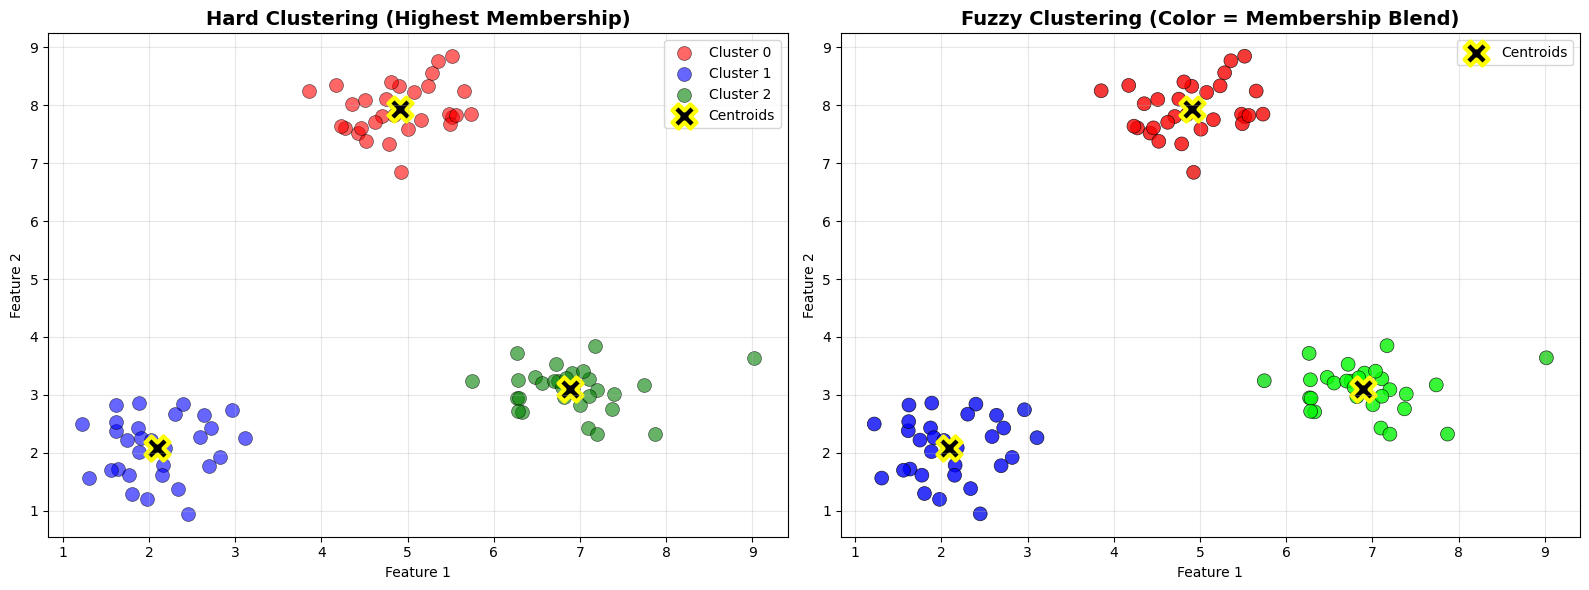


In the fuzzy plot, points with mixed colors have membership in multiple clusters!


In [7]:
# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['red', 'blue', 'green']

# Plot 1: Hard clustering (like K-means)
ax1 = axes[0]
for i in range(fcm.n_clusters):
    cluster_points = X[labels == i]
    ax1.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}', alpha=0.6, s=100,
                edgecolors='black', linewidths=0.5)

# Plot centroids
ax1.scatter(fcm.centroids[:, 0], fcm.centroids[:, 1], 
            c='black', marker='X', s=300, edgecolors='yellow', linewidths=3,
            label='Centroids')

ax1.set_title('Hard Clustering (Highest Membership)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Fuzzy clustering with membership-based coloring
ax2 = axes[1]

# Use membership values to create RGB colors
# Each point's color is a weighted combination of cluster colors
rgb_colors = torch.zeros(X.shape[0], 3)
rgb_map = torch.tensor([[1.0, 0.0, 0.0],  # Red for cluster 0
                         [0.0, 0.0, 1.0],  # Blue for cluster 1
                         [0.0, 1.0, 0.0]]) # Green for cluster 2

for i in range(fcm.n_clusters):
    rgb_colors += fcm.membership[:, i].unsqueeze(1) * rgb_map[i]

ax2.scatter(X[:, 0], X[:, 1], c=rgb_colors, s=100, alpha=0.8,
           edgecolors='black', linewidths=0.5)

# Plot centroids
ax2.scatter(fcm.centroids[:, 0], fcm.centroids[:, 1], 
            c='black', marker='X', s=300, edgecolors='yellow', linewidths=3,
            label='Centroids')

ax2.set_title('Fuzzy Clustering (Color = Membership Blend)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nIn the fuzzy plot, points with mixed colors have membership in multiple clusters!")

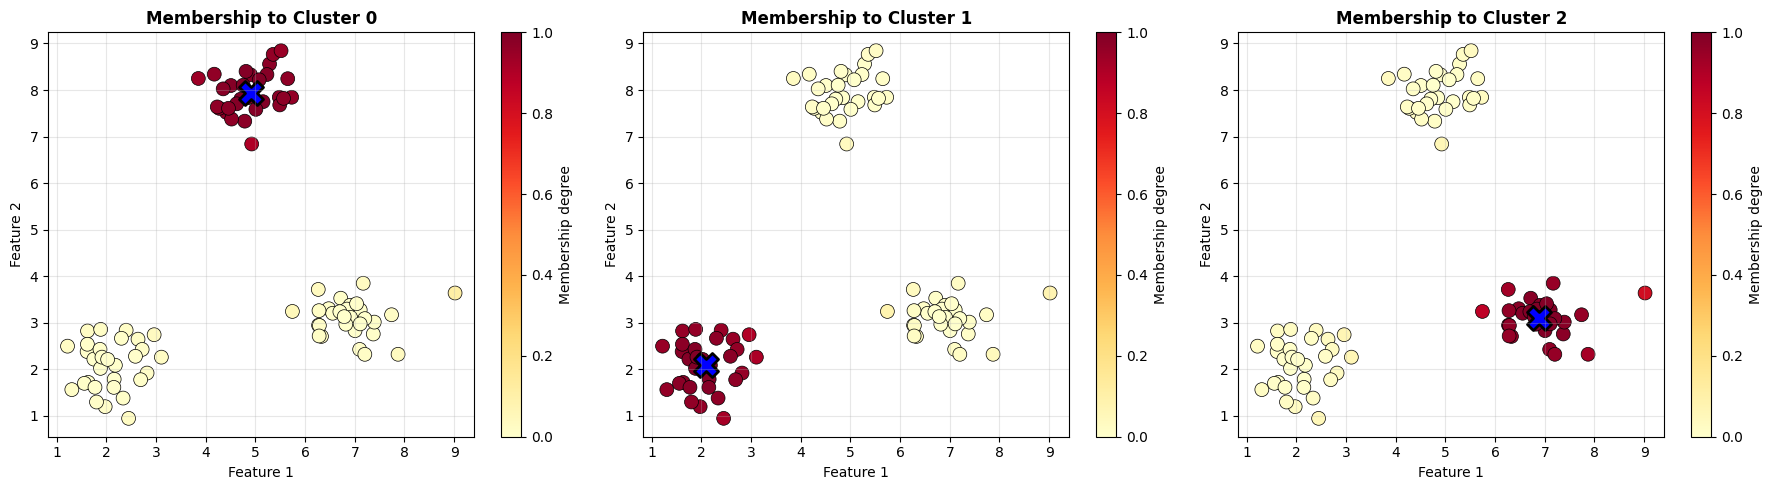

Darker colors = higher membership to that cluster


In [8]:
# Create heatmaps showing membership degree for each cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(fcm.n_clusters):
    ax = axes[i]
    
    # Plot points with color intensity based on membership
    scatter = ax.scatter(X[:, 0], X[:, 1], 
                        c=fcm.membership[:, i], 
                        cmap='YlOrRd', s=100, 
                        vmin=0, vmax=1,
                        edgecolors='black', linewidths=0.5)
    
    # Plot centroid
    ax.scatter(fcm.centroids[i, 0], fcm.centroids[i, 1], 
              c='blue', marker='X', s=300, edgecolors='black', linewidths=2)
    
    ax.set_title(f'Membership to Cluster {i}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax, label='Membership degree')

plt.tight_layout()
plt.show()

print("Darker colors = higher membership to that cluster")

In [9]:
print("=" * 60)
print("SIMPLE EXAMPLE: 4 Points, 2 Clusters")
print("=" * 60)

# Create 4 simple data points
simple_data = torch.tensor([
    [1.0, 1.0],
    [1.5, 2.0],
    [5.0, 8.0],
    [8.0, 8.0]
])

print(f"\nData points:")
for i, point in enumerate(simple_data):
    print(f"  P{i+1}: {point.tolist()}")

print()

SIMPLE EXAMPLE: 4 Points, 2 Clusters

Data points:
  P1: [1.0, 1.0]
  P2: [1.5, 2.0]
  P3: [5.0, 8.0]
  P4: [8.0, 8.0]



In [10]:
# Apply Fuzzy C-Means with 2 clusters
print("\n" + "=" * 60)
print("APPLYING FUZZY C-MEANS (m=2.0)")
print("=" * 60 + "\n")

fcm_simple = FuzzyCMeans(n_clusters=2, m=2.0, max_iters=50, tolerance=1e-6)
fcm_simple.fit(simple_data)
simple_labels = fcm_simple.predict(simple_data)

print(f"\n" + "=" * 60)
print("MEMBERSHIP DEGREES")
print("=" * 60)
print(f"{'Point':<8} {'Position':<15} {'Cluster 0':<12} {'Cluster 1':<12} {'Assigned'}")
print("=" * 60)

for i in range(len(simple_data)):
    pos = f"({simple_data[i, 0]:.1f}, {simple_data[i, 1]:.1f})"
    m0 = fcm_simple.membership[i, 0].item()
    m1 = fcm_simple.membership[i, 1].item()
    assigned = simple_labels[i].item()
    print(f"P{i+1:<7d} {pos:<15s} {m0:.4f}       {m1:.4f}       Cluster {assigned}")


APPLYING FUZZY C-MEANS (m=2.0)

Training Fuzzy C-Means with 2 clusters
Fuzziness parameter (m): 2.0
Max iterations: 50

Iteration   0: Objective = 34.8890, Membership change = 0.105442

Converged at iteration 5

Final objective: 4.9785

Centroids:
tensor([[1.2547, 1.5066],
        [6.5234, 7.9999]])

MEMBERSHIP DEGREES
Point    Position        Cluster 0    Cluster 1    Assigned
P1       (1.0, 1.0)      0.9960       0.0040       Cluster 0
P2       (1.5, 2.0)      0.9951       0.0049       Cluster 0
P3       (5.0, 8.0)      0.0397       0.9603       Cluster 1
P4       (8.0, 8.0)      0.0243       0.9757       Cluster 1


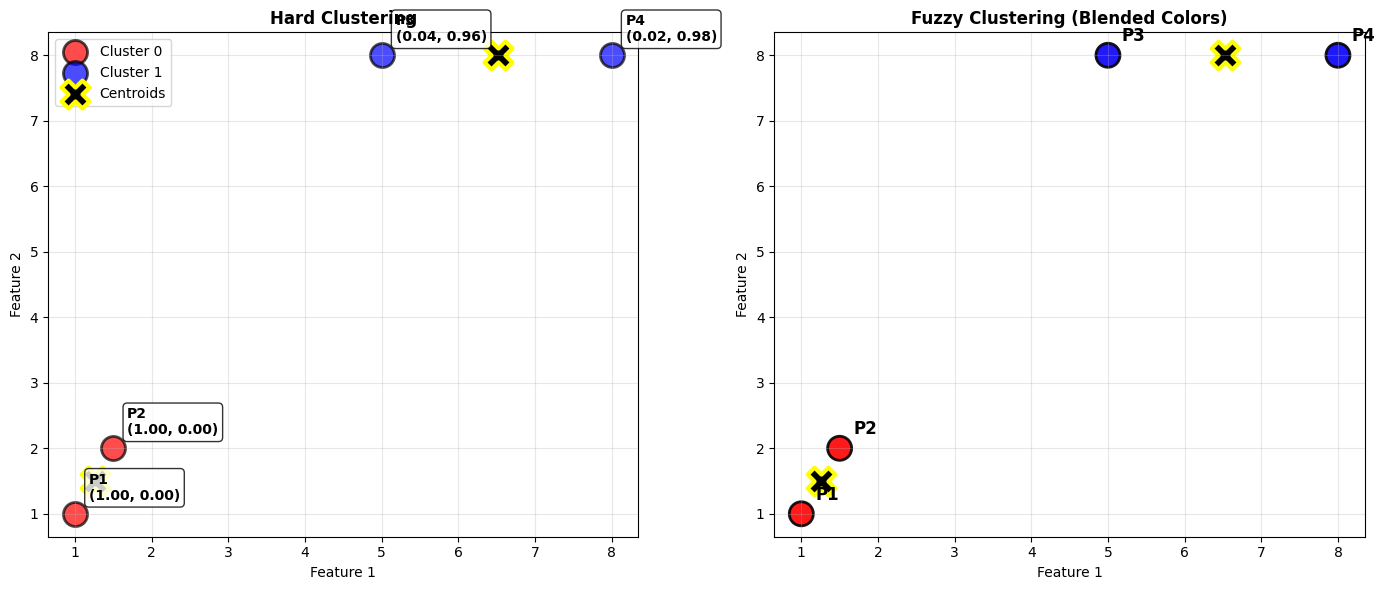

In [11]:
# Visualize simple example
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_simple = ['red', 'blue']

# Plot 1: Hard clustering
ax1 = axes[0]
for i in range(2):
    cluster_points = simple_data[simple_labels == i]
    ax1.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors_simple[i], s=300, label=f'Cluster {i}', 
                alpha=0.7, edgecolors='black', linewidths=2)

# Plot centroids
ax1.scatter(fcm_simple.centroids[:, 0], fcm_simple.centroids[:, 1], 
            c='black', marker='X', s=400, edgecolors='yellow', linewidths=3,
            label='Centroids')

# Annotate points with memberships
for i, point in enumerate(simple_data):
    m0 = fcm_simple.membership[i, 0].item()
    m1 = fcm_simple.membership[i, 1].item()
    ax1.annotate(f'P{i+1}\n({m0:.2f}, {m1:.2f})', 
                xy=point, xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.set_title('Hard Clustering', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Fuzzy visualization with blended colors
ax2 = axes[1]

# Create RGB colors based on membership
rgb_simple = torch.zeros(simple_data.shape[0], 3)
rgb_map_simple = torch.tensor([[1.0, 0.0, 0.0],  # Red
                                [0.0, 0.0, 1.0]]) # Blue

for i in range(2):
    rgb_simple += fcm_simple.membership[:, i].unsqueeze(1) * rgb_map_simple[i]

ax2.scatter(simple_data[:, 0], simple_data[:, 1], 
           c=rgb_simple, s=300, alpha=0.9,
           edgecolors='black', linewidths=2)

# Plot centroids
ax2.scatter(fcm_simple.centroids[:, 0], fcm_simple.centroids[:, 1], 
            c='black', marker='X', s=400, edgecolors='yellow', linewidths=3)

# Annotate points
for i, point in enumerate(simple_data):
    ax2.annotate(f'P{i+1}', xy=point, xytext=(10, 10), 
                textcoords='offset points', fontsize=12, fontweight='bold')

ax2.set_title('Fuzzy Clustering (Blended Colors)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Training Fuzzy C-Means with 3 clusters
Fuzziness parameter (m): 1.5
Max iterations: 100

Iteration   0: Objective = 560.4230, Membership change = 10.239137

Converged at iteration 5

Final objective: 42.9995

Centroids:
tensor([[6.9060, 3.1002],
        [2.1001, 2.0909],
        [4.9084, 7.9365]])
Training Fuzzy C-Means with 3 clusters
Fuzziness parameter (m): 2.0
Max iterations: 100

Iteration   0: Objective = 323.4285, Membership change = 8.298445

Converged at iteration 7

Final objective: 40.3825

Centroids:
tensor([[6.8892, 3.0989],
        [2.0934, 2.0907],
        [4.9098, 7.9347]])
Training Fuzzy C-Means with 3 clusters
Fuzziness parameter (m): 3.0
Max iterations: 100

Iteration   0: Objective = 107.5695, Membership change = 7.976339

Converged at iteration 9

Final objective: 24.6861

Centroids:
tensor([[6.8591, 3.1147],
        [2.0679, 2.0926],
        [4.9045, 7.9257]])
Training Fuzzy C-Means with 3 clusters
Fuzziness parameter (m): 5.0
Max iterations: 100

Iteration   0: O

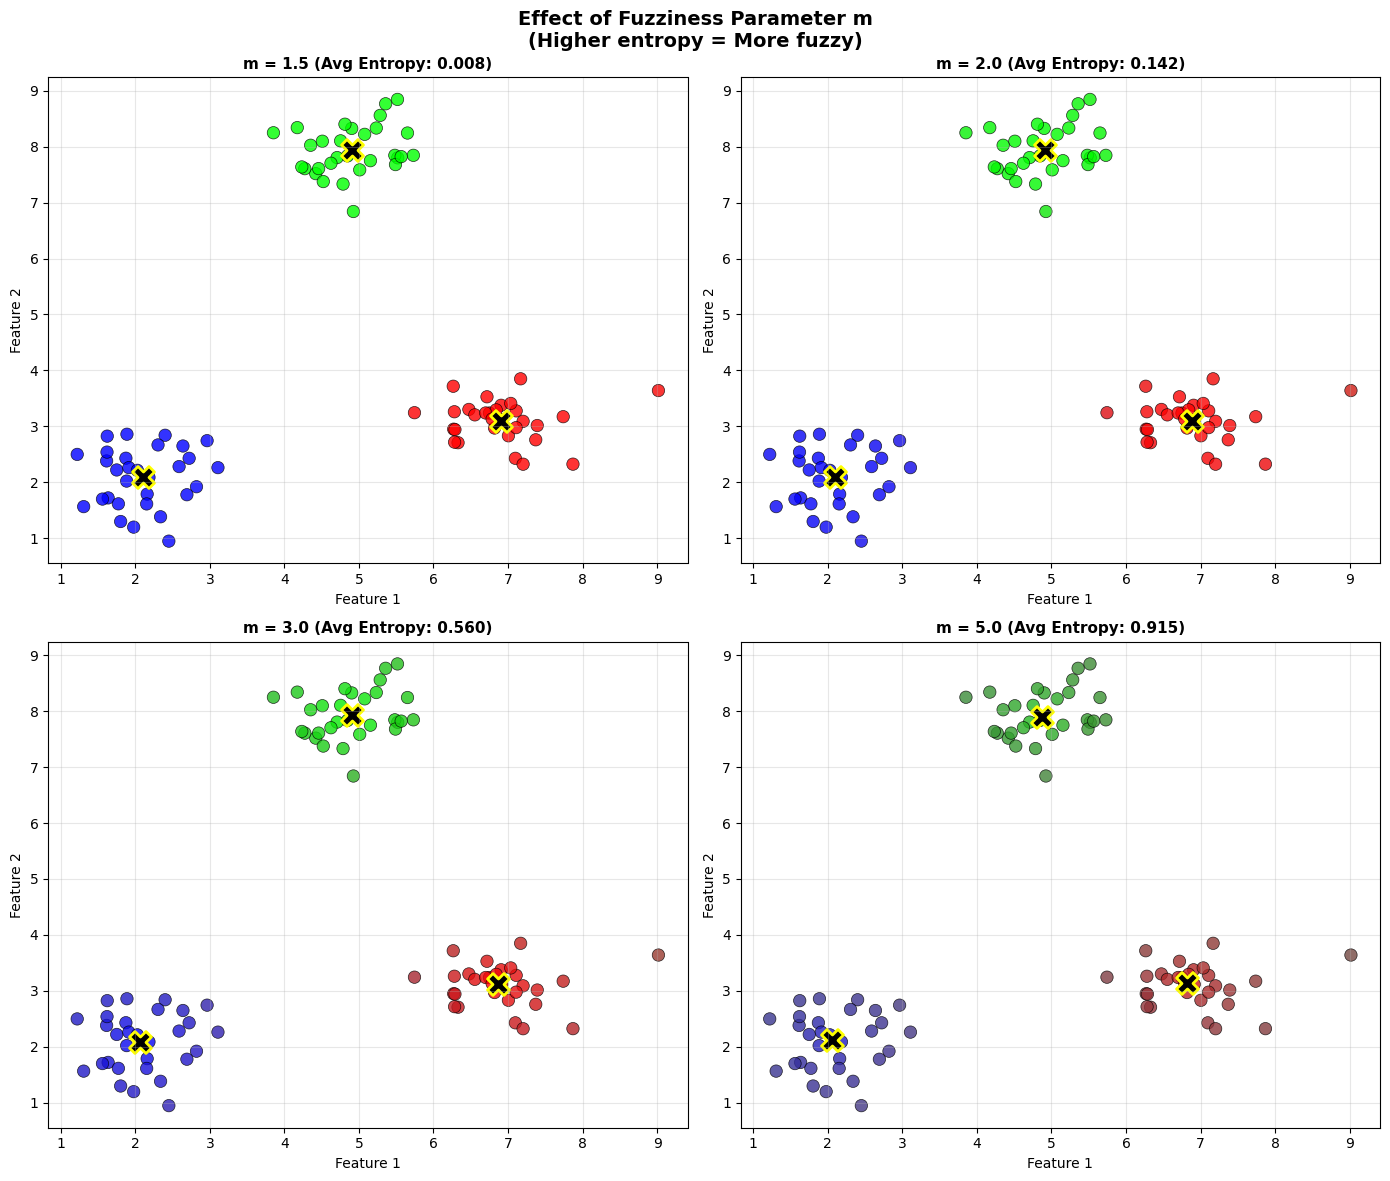


Effect of m:
- m → 1: Approaches hard clustering (like K-means)
- m = 2: Most common, moderate fuzziness
- m > 2: More fuzzy boundaries, mixed colors near borders
- m → ∞: All points have equal membership to all clusters


In [12]:
# Try different fuzziness values
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

m_values = [1.5, 2.0, 3.0, 5.0]

for idx, m_val in enumerate(m_values):
    ax = axes[idx]
    
    # Train FCM with different m
    fcm_temp = FuzzyCMeans(n_clusters=3, m=m_val, max_iters=100, tolerance=1e-4)
    fcm_temp.fit(X)
    
    # Create fuzzy colors
    rgb_colors_temp = torch.zeros(X.shape[0], 3)
    for i in range(3):
        rgb_colors_temp += fcm_temp.membership[:, i].unsqueeze(1) * rgb_map[i]
    
    # Plot
    ax.scatter(X[:, 0], X[:, 1], c=rgb_colors_temp, s=80, alpha=0.8,
              edgecolors='black', linewidths=0.5)
    
    # Plot centroids
    ax.scatter(fcm_temp.centroids[:, 0], fcm_temp.centroids[:, 1], 
              c='black', marker='X', s=250, edgecolors='yellow', linewidths=2)
    
    # Calculate average membership entropy (measure of fuzziness)
    epsilon = 1e-10
    entropy = -torch.sum(fcm_temp.membership * torch.log(fcm_temp.membership + epsilon), dim=1)
    avg_entropy = entropy.mean().item()
    
    ax.set_title(f'm = {m_val} (Avg Entropy: {avg_entropy:.3f})', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Fuzziness Parameter m\n(Higher entropy = More fuzzy)', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEffect of m:")
print("- m → 1: Approaches hard clustering (like K-means)")
print("- m = 2: Most common, moderate fuzziness")
print("- m > 2: More fuzzy boundaries, mixed colors near borders")
print("- m → ∞: All points have equal membership to all clusters")

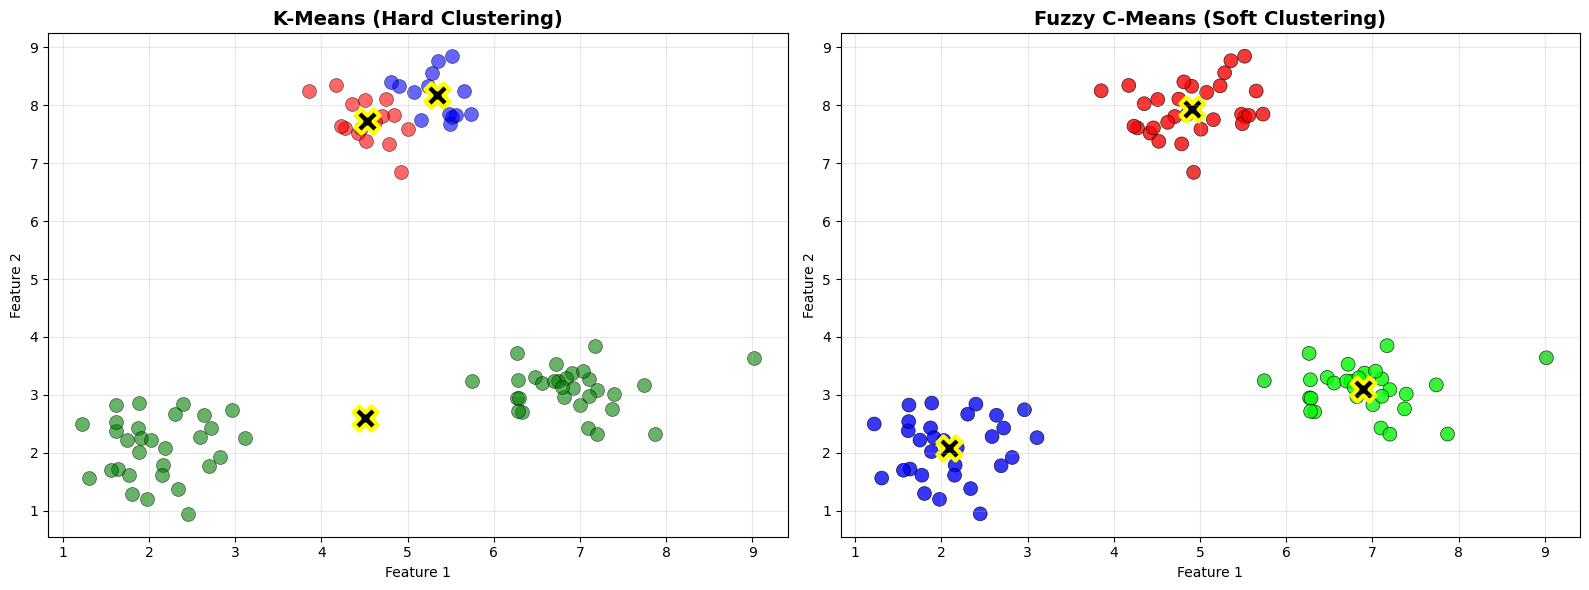


Key Differences:
- K-Means: Each point belongs to exactly one cluster (hard assignment)
- Fuzzy C-Means: Each point has membership degrees to all clusters (soft assignment)
- FCM is better for overlapping clusters or uncertain boundaries


In [13]:
# Simple K-Means for comparison
class SimpleKMeans:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.centroids = None
        self.labels = None
    
    def fit(self, X):
        # Initialize centroids randomly
        n_samples = X.shape[0]
        indices = torch.randperm(n_samples)[:self.n_clusters]
        self.centroids = X[indices].clone()
        
        for _ in range(50):
            # Assign clusters
            distances = torch.cdist(X, self.centroids)
            self.labels = torch.argmin(distances, dim=1)
            
            # Update centroids
            for k in range(self.n_clusters):
                cluster_points = X[self.labels == k]
                if len(cluster_points) > 0:
                    self.centroids[k] = cluster_points.mean(dim=0)
        
        return self

# Train K-Means
kmeans_compare = SimpleKMeans(n_clusters=3)
kmeans_compare.fit(X)

# Compare visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
ax1 = axes[0]
for i in range(3):
    cluster_points = X[kmeans_compare.labels == i]
    ax1.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], alpha=0.6, s=100, edgecolors='black', linewidths=0.5)
ax1.scatter(kmeans_compare.centroids[:, 0], kmeans_compare.centroids[:, 1], 
            c='black', marker='X', s=300, edgecolors='yellow', linewidths=3)
ax1.set_title('K-Means (Hard Clustering)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

# Fuzzy C-Means
ax2 = axes[1]
rgb_colors_final = torch.zeros(X.shape[0], 3)
for i in range(3):
    rgb_colors_final += fcm.membership[:, i].unsqueeze(1) * rgb_map[i]
ax2.scatter(X[:, 0], X[:, 1], c=rgb_colors_final, s=100, alpha=0.8,
           edgecolors='black', linewidths=0.5)
ax2.scatter(fcm.centroids[:, 0], fcm.centroids[:, 1], 
            c='black', marker='X', s=300, edgecolors='yellow', linewidths=3)
ax2.set_title('Fuzzy C-Means (Soft Clustering)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print("- K-Means: Each point belongs to exactly one cluster (hard assignment)")
print("- Fuzzy C-Means: Each point has membership degrees to all clusters (soft assignment)")
print("- FCM is better for overlapping clusters or uncertain boundaries")